# 🚀 Modernized pypff Interactive Demo

This notebook demonstrates the high-performance, zero-copy features of the modernized `pypff` package using interactive widgets.

### Key Concepts:
- **`PanosetiRun`**: Automated discovery of data products and configurations.
- **`PFFSequence`**: Optimized `mmap`-based stream access.
- **Interactive Exploration**: Use sliders and dropdowns to browse large datasets instantly.

In [1]:
%matplotlib inline
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from pypff import PanosetiRun, PFFSequence, hkpff
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from tqdm.notebook import tqdm

# Set path to example data
example_data_dir = Path("./example-data")

if not example_data_dir.exists():
    print("❌ Example data directory not found. Please ensure you are in the pypff/example directory.")

## 1. Initialize the Run

Scanning the directory to discover available products and configuration metadata.

In [2]:
run = PanosetiRun(example_data_dir)
products = run.list_products()

print(f"✅ Loaded Run: {run.run_dir.name}")
print(f"Found {len(products)} Data Products.")
run.show()

✅ Loaded Run: example-data
Found 2 Data Products.


Run: example-data
├── Configurations
│   ├── daq_config.json
│   ├── data_config.json
│   ├── obs_config.json
│   ├── quabo_config_192.168.3.248.json
│   ├── quabo_config_192.168.3.249.json
│   ├── quabo_config_192.168.3.250.json
│   ├── quabo_config_192.168.3.251.json
│   ├── quabo_config_debug.json
│   ├── quabo_ph_baseline.json
│   ├── quabo_uids.json
│   └── sw_info.json
├── Metadata & Logs
│   ├── hk.pff
│   └── log.txt
└── Data Products
    ├── dp_img16.bpp_2.module_1 (10,002 frames)
    └── dp_ph256.bpp_2.module_254 (15,059 frames)

In [8]:
run.list_products()

['dp_img16.bpp_2.module_1', 'dp_ph256.bpp_2.module_254']

In [15]:
seq2 = run.get_product('dp_img16.bpp_2.module_1')
seq2.metadata_offsets

{'quabo_0.pkt_num': (28, 39),
 'quabo_0.pkt_tai': (51, 56),
 'quabo_0.pkt_nsec': (69, 79),
 'quabo_0.tv_sec': (90, 101),
 'quabo_0.tv_usec': (113, 120),
 'quabo_1.pkt_num': (150, 161),
 'quabo_1.pkt_tai': (173, 178),
 'quabo_1.pkt_nsec': (191, 201),
 'quabo_1.tv_sec': (212, 223),
 'quabo_1.tv_usec': (235, 242),
 'quabo_2.pkt_num': (272, 283),
 'quabo_2.pkt_tai': (295, 300),
 'quabo_2.pkt_nsec': (313, 323),
 'quabo_2.tv_sec': (334, 345),
 'quabo_2.tv_usec': (357, 364),
 'quabo_3.pkt_num': (394, 405),
 'quabo_3.pkt_tai': (417, 422),
 'quabo_3.pkt_nsec': (435, 445),
 'quabo_3.tv_sec': (456, 467),
 'quabo_3.tv_usec': (479, 486)}

In [22]:
seq2.get_frame(10)

(ModuleHeader(quabo_0=PFFHeader(pkt_num=2009, pkt_tai=400, pkt_nsec=530007492, tv_sec=1686198635, tv_usec=530460), quabo_1=PFFHeader(pkt_num=1858, pkt_tai=400, pkt_nsec=530007488, tv_sec=1686198635, tv_usec=530461), quabo_2=PFFHeader(pkt_num=1699, pkt_tai=400, pkt_nsec=530007488, tv_sec=1686198635, tv_usec=530500), quabo_3=PFFHeader(pkt_num=1561, pkt_tai=400, pkt_nsec=530007492, tv_sec=1686198635, tv_usec=530501)),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(32, 32), dtype=uint16))

In [23]:
seq2.get_frame_time(10)

1686198635530007492

## 2. Time-Multiplexed Interleaving Analysis

PanoSETI often operates in an interleaved mode, switching between high-rate Pulse Height detection and standard Movie-mode imaging. 

The following visualization analyzes the collection rate and scheduling of all discovered data products simultaneously.

Scanning Timestamps:   0%|          | 0/2 [00:00<?, ?it/s]

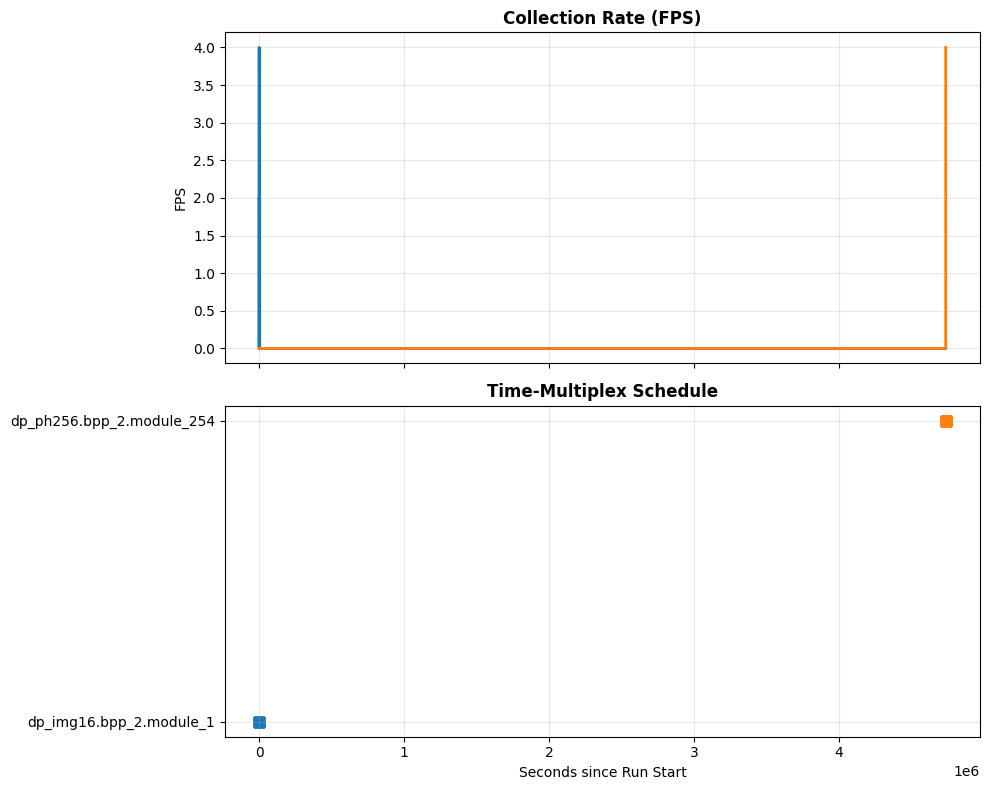

In [ ]:
def extract_timeline(run_obj, sample_rate=1000, precise=True):
    data = {}
    for prod_name in tqdm(run_obj.list_products(), desc="Scanning Timestamps"):
        seq = run_obj.get_product(prod_name)
        if len(seq) == 0: continue
        
        # Optimized: pre-index all timestamps
        # seq.index_timestamps(precise=precise)
        
        # Sample timestamps across the sequence
        indices = list(range(0, len(seq), sample_rate))
        if indices[-1] != len(seq) - 1: indices.append(len(seq) - 1)
        
        times = np.array([seq.get_frame_time(i, precise=precise) / 1e9 for i in indices])
        data[prod_name] = {"times": times, "indices": np.array(indices)}
    return data

sample_rate = 100
timeline = extract_timeline(run, sample_rate)

if timeline:
    # Normalize time to start of run
    t0 = min([d["times"].min() for d in timeline.values()])
    max_t = max([d["times"].max() for d in timeline.values()]) - t0
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    
    bin_size = 0.5
    bins = np.arange(0, max_t + bin_size, bin_size)
    colors = plt.cm.tab10.colors
    
    for i, (name, d) in enumerate(timeline.items()):
        norm_times = d["times"] - t0
        counts, _ = np.histogram(norm_times, bins=bins)
        fps = (counts / bin_size) * sample_rate
        
        color = colors[i % len(colors)]
        
        # Rate Plot
        ax1.step(bins[:-1], fps, where='post', label=name, color=color, linewidth=2)
        ax1.fill_between(bins[:-1], fps, step='post', color=color, alpha=0.3)
        
        # Gantt Plot (Blocks indicate activity)
        active_bins = bins[:-1][fps > 0]
        ax2.scatter(active_bins, [name] * len(active_bins), marker='s', s=50, color=color, label=name)

    ax1.set_title('Collection Rate (FPS)', fontweight='bold')
    ax1.set_ylabel('FPS')
    ax1.grid(True, alpha=0.3)
    
    ax2.set_title('Time-Multiplex Schedule', fontweight='bold')
    ax2.set_xlabel('Seconds since Run Start')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 3. Interactive Frame Explorer

Select a product and navigate through frames using the slider.

In [4]:
product_dropdown = widgets.Dropdown(
    options=products,
    description='Product:',
    disabled=False,
)

frame_slider = widgets.IntSlider(
    min=0,
    max=100,
    step=1,
    description='Frame:',
    continuous_update=True,
    layout=widgets.Layout(width='500px')
)

out = widgets.Output()

def update_display(change=None):
    product_name = product_dropdown.value
    seq = run.get_product(product_name)
    frame_slider.max = len(seq) - 1
    
    frame_idx = frame_slider.value
    header, image = seq.get_frame(frame_idx)
    
    with out:
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(8, 6))
        im = ax.imshow(image, cmap='magma', interpolation='nearest', origin='lower')
        fig.colorbar(im, ax=ax, label='ADC Value')
        
        # Handle different header types
        pkt_num = header.pkt_num if hasattr(header, 'pkt_num') else header.quabo_0.pkt_num
            
        ax.set_title(f"{product_name}\nFrame {frame_idx} | Packet {pkt_num} | {header.timestamp_ns} ns", loc='left')
        plt.show()

product_dropdown.observe(update_display, names='value')
frame_slider.observe(update_display, names='value')
update_display()

display(widgets.VBox([product_dropdown, frame_slider, out]))

## 4. Multi-Frame Grid Sample

Visualizing a sequence of frames from each product to inspect temporal variations.

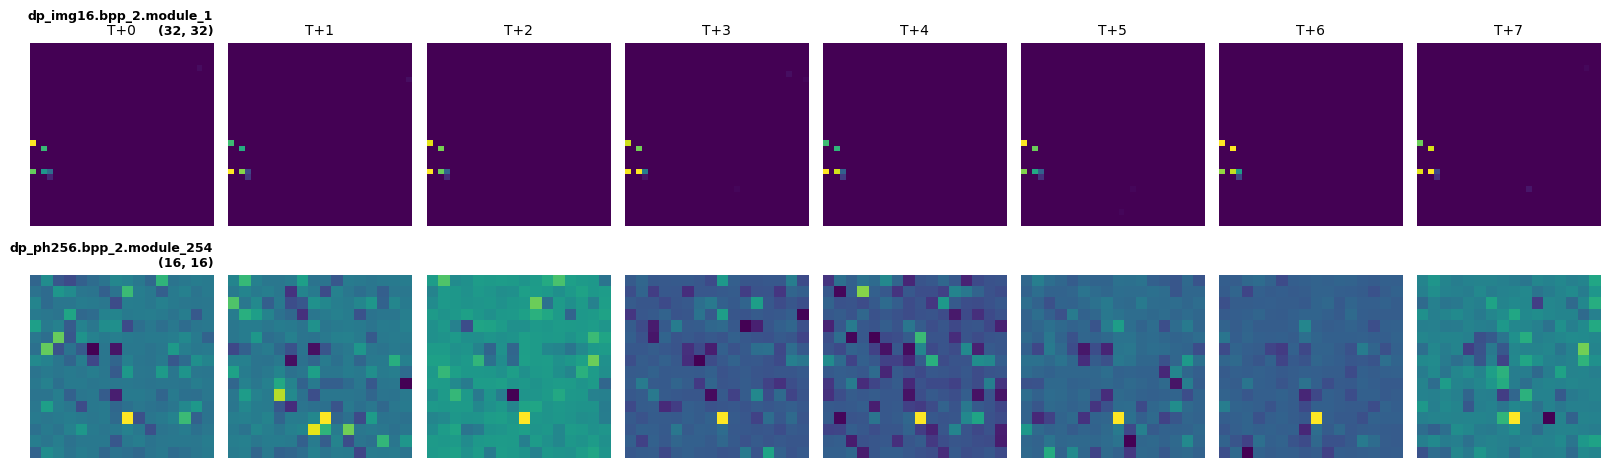

In [7]:
n_samples = 8
fig, axes = plt.subplots(len(products), n_samples, figsize=(2 * n_samples, 2.5 * len(products)), squeeze=False)

for row_idx, name in enumerate(products):
    seq = run.get_product(name)
    images = seq.get_image_array(start=0, count=n_samples)
    
    for col_idx in range(n_samples):
        ax = axes[row_idx, col_idx]
        ax.imshow(images[col_idx], cmap='viridis', origin='lower')
        ax.axis('off')
        if col_idx == 0:
            ax.set_title(f"{name}\n{seq.frame_config.image_shape}", loc='right', fontweight='bold', fontsize=9)
        if row_idx == 0:
            ax.set_title(f"T+{col_idx}", fontsize=10)

plt.tight_layout()
plt.show()

## 5. Interactive Housekeeping Monitor

Explore telemetry parameters from the housekeeping stream.

In [6]:
hk_data = hkpff(example_data_dir / "hk.pff").readhk()

device_select = widgets.Select(options=sorted(hk_data.keys()), description='Device:')
param_select = widgets.Select(options=[], description='Param:')
hk_out = widgets.Output()

def update_params(change=None):
    device = device_select.value
    param_select.options = sorted(hk_data[device].keys())

def update_hk_plot(change=None):
    device = device_select.value
    param = param_select.value
    if not param: return
    
    values = hk_data[device][param]
    with hk_out:
        clear_output(wait=True)
        plt.figure(figsize=(10, 4))
        plt.plot(values, color='tab:blue', alpha=0.8)
        plt.title(f"{device} - {param}")
        plt.grid(True, alpha=0.3)
        plt.show()

device_select.observe(update_params, names='value')
device_select.observe(update_hk_plot, names='value')
param_select.observe(update_hk_plot, names='value')

update_params()
update_hk_plot()
display(widgets.HBox([device_select, param_select]), hk_out)

Output()